# FPCA for Intraday Cumulative Log-Returns

This notebook applies **functional principal component analysis (FPCA)** to the **intraday cumulative log-returns** of a financial asset, built from the tick data in `out28.csv`.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from scipy.stats import chi2, norm

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['figure.dpi'] = 120

## 1. Loading the ticks and building (Y_n(t_j))

We load `out28.csv`, keep the columns `day`, `tick`, `logprice`, and then construct:

* a regular intraday grid (t_j) (for example 100 points between the first and the last tick),
* for each day (n), the intraday cumulative log-returns $Y_n(t)$ obtained using a **“previous tick”** interpolation.


In [5]:
def load_ticks(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [str(c).strip().lower() for c in df.columns]
    df = df[['day', 'tick', 'logprice']]
    df['day'] = pd.to_numeric(df['day'], errors='coerce').astype('Int64')
    df['tick'] = pd.to_numeric(df['tick'], errors='coerce')
    df['logprice'] = pd.to_numeric(df['logprice'], errors='coerce')
    df = df.dropna(subset=['day', 'tick', 'logprice']).reset_index(drop=True)
    df['day'] = df['day'].astype(int)
    df = df.sort_values(['day', 'tick']).reset_index(drop=True)
    return df


def build_intraday_matrix(path: str, J_grid: int = 100):
    """Build Y_n(t_j) on a regular grid using a “previous tick” interpolation within each day.

    Returns:
    - days: sorted list/array of days
    - t_grid: common intraday grid of shape (J_grid,)
    - Y: N x J_grid matrix of intraday cumulative log-returns
    """

    df = load_ticks(path)

    t_min = df['tick'].min()
    t_max = df['tick'].max()
    t_grid = np.linspace(t_min, t_max, J_grid)

    days = np.sort(df['day'].unique())
    N = len(days)
    J = J_grid
    Y = np.empty((N, J))

    for i, d in enumerate(days):
        sub = df[df['day'] == d]
        ticks = sub['tick'].to_numpy()
        prices = sub['logprice'].to_numpy()

        # sort
        order = np.argsort(ticks)
        ticks = ticks[order]
        prices = prices[order]

        base = prices[0]

        # indices of the last tick <= t_j (“previous tick” interpolation)
        idx = np.searchsorted(ticks, t_grid, side='right') - 1
        idx[idx < 0] = 0
        logP_day = prices[idx]

        Y[i, :] = logP_day - base

    return days, t_grid, Y


path = 'out28.csv'
days, t_grid, Y = build_intraday_matrix(path, J_grid=100)
N, J = Y.shape
print('N jours =', N)
print('J points intraday (grille régulière) =', J)

N jours = 754
J points intraday (grille régulière) = 100


## 2. Statistical analysis of the intraday trajectories

We plot a few intraday cumulative return curves $Y_n(t)$, together with the estimated functional mean $\hat\mu(t)$.


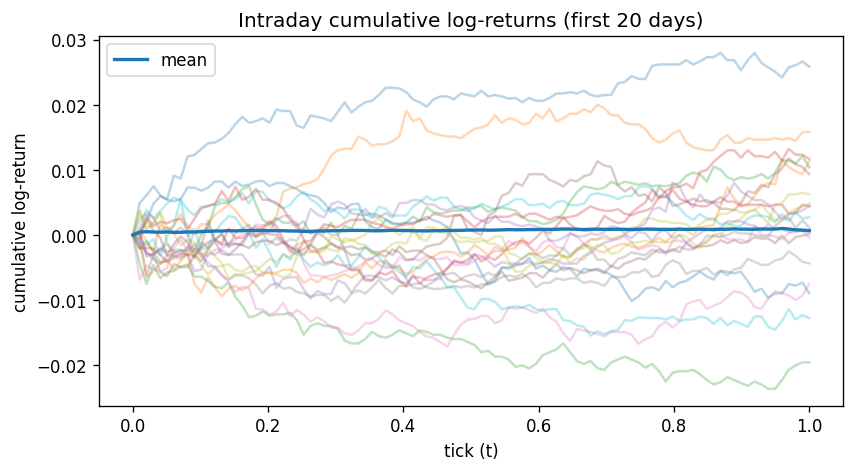

In [6]:
mu_hat = Y.mean(axis=0)
var_hat = Y.var(axis=0, ddof=0)

plt.figure()
for n in range(min(20, N)):
    plt.plot(t_grid, Y[n, :], alpha=0.3)
plt.plot(t_grid, mu_hat, linewidth=2, label='mean')
plt.xlabel('tick (t)')
plt.ylabel('cumulative log-return')
plt.title('Intraday cumulative log-returns (first 20 days)')
plt.legend()
plt.show()

We can see that the intraday trajectories $Y_n(t)$ fluctuate around zero, with typical amplitudes of about **2–3%** in cumulative log-return. The estimated mean curve $\hat\mu(t)$ is almost perfectly flat and very close to zero, which is consistent with the idea that, over a full day, there is no strong systematic trend. However, from one day to another, the curve shape can be slightly upward or downward, which motivates using a functional model to describe these day-to-day profile differences.


## 3. Discrete FPCA: covariance, eigenfunctions, and scores

We first center the data, then compute the sample covariance matrix. From this matrix, we extract the eigenvalues, eigenfunctions, and the corresponding functional scores.


Premières valeurs propres et PVE :
k=1, eigenvalue=4.9640e-03, PVE=0.8708
k=2, eigenvalue=3.6703e-04, PVE=0.9352
k=3, eigenvalue=1.2725e-04, PVE=0.9575
k=4, eigenvalue=5.6491e-05, PVE=0.9674
k=5, eigenvalue=3.6037e-05, PVE=0.9737
k=6, eigenvalue=2.3865e-05, PVE=0.9779
k=7, eigenvalue=1.9121e-05, PVE=0.9812
k=8, eigenvalue=1.4268e-05, PVE=0.9838
k=9, eigenvalue=9.5056e-06, PVE=0.9854
k=10, eigenvalue=8.6236e-06, PVE=0.9869


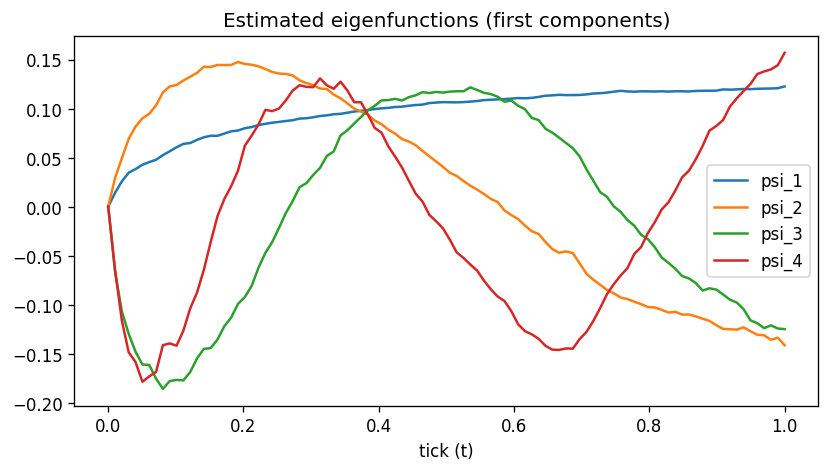

In [7]:
#  Center the curves
Z = Y - mu_hat

# Sample covariance matrix (J x J) on the intraday grid
C = (Z.T @ Z) / N

# Spectral decomposition
eigvals, eigvecs = np.linalg.eigh(C)
#Sort components in decreasing order of eigenvalues
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Cumulative proportion of variance explained  (PVE)
pve = np.cumsum(eigvals) / eigvals.sum()

print('Premières valeurs propres et PVE :')
for k in range(min(10, J)):
    print(f'k={k+1}, eigenvalue={eigvals[k]:.4e}, PVE={pve[k]:.4f}')

# Eigenfunctions
p_max_plot = min(4, J)
plt.figure()
for k in range(p_max_plot):
    plt.plot(t_grid, eigvecs[:, k], label=f'psi_{k+1}')
plt.xlabel('tick (t)')
plt.title('Estimated eigenfunctions (first components)')
plt.legend()
plt.show()

# functional scores
dt = float(np.mean(np.diff(t_grid)))
p_max = min(10, J)
Psi = eigvecs[:, :p_max]
Xi = Z @ (Psi * dt)

The first eigenvalues show that a single principal component already explains about **87%** of the total variance, and the first two explain more than **93%**. This means that most of the variability in intraday trajectories can be summarized with just one or two factors.

The first eigenfunction $\psi_1(t)$ is positive throughout the day and slightly increasing. It corresponds to a **level/trend factor**: a positive score $\xi_{n1}$ gives a globally more upward day, while a negative score gives a more downward day, with a fairly smooth overall shape.

The next eigenfunctions $(\psi_2,\psi_3,\psi_4)$ change sign and show peaks/valleys around the middle of the session. They capture **slope effects** (opposing the start and the end of the day) and **curvature effects** (more or less movement around midday). For example, a positive score on $\psi_2$ can correspond to a day that rises early and then flattens, while a negative score gives the opposite pattern.

Overall, these results are very consistent with the idea that intraday profiles can be described by a small number of interpretable factors: one main level factor and a few shape factors (slope, curvature).


## 4. Score distributions, normality test (Jarque–Bera), and QQ-plots


Score k = 1
  mean = -4.6014e-21
  var = 5.0710e-07
  skew = 9.9987e-02
  kurt = 3.8940e+00
  JB = 2.6366e+01
  JB_pvalue = 1.8819e-06


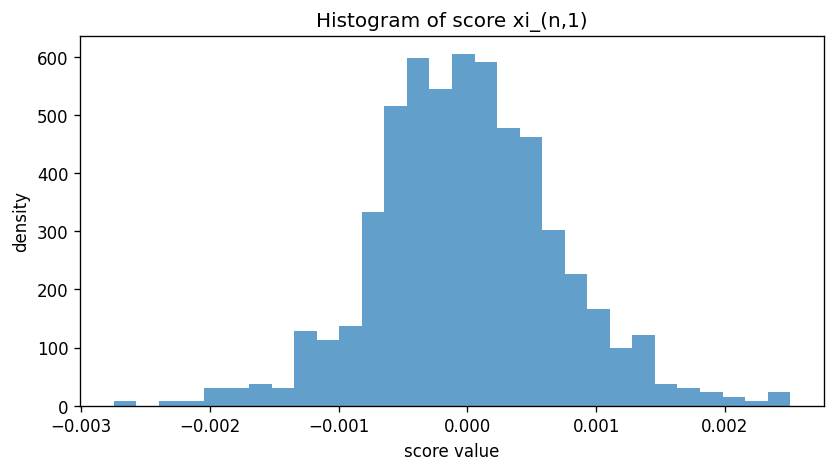

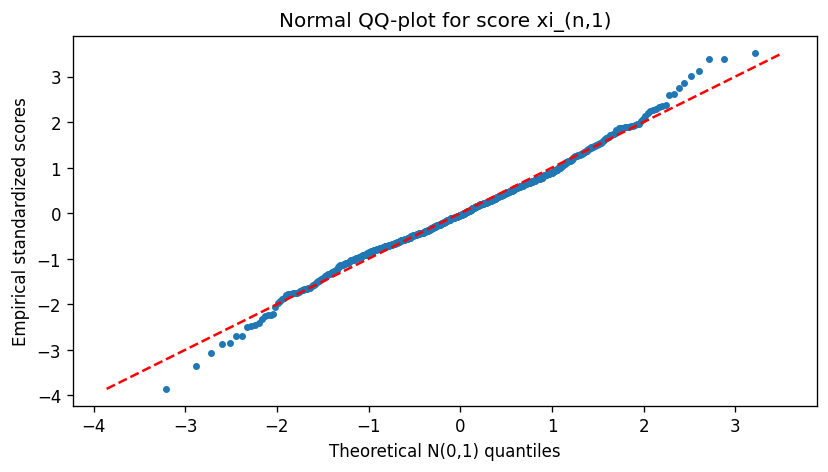


Score k = 2
  mean = 8.6276e-21
  var = 3.7494e-08
  skew = 3.2196e-01
  kurt = 4.0168e+00
  JB = 4.5505e+01
  JB_pvalue = 1.3144e-10


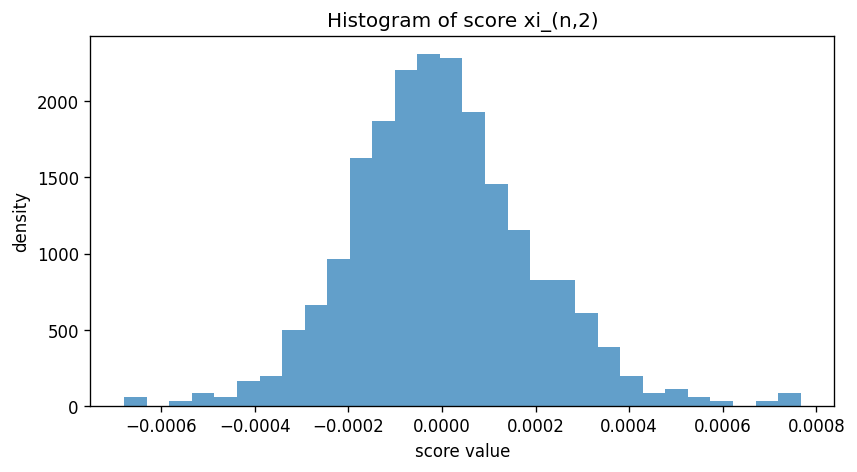

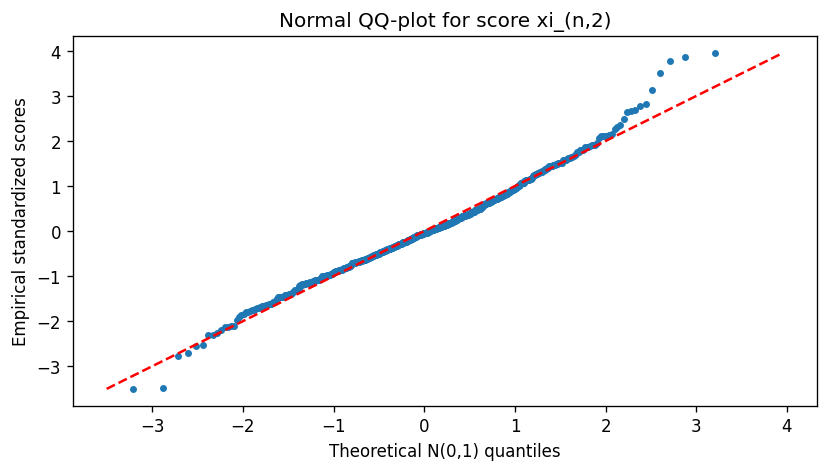


Score k = 3
  mean = 1.7255e-21
  var = 1.2999e-08
  skew = -4.2218e-02
  kurt = 5.0725e+00
  JB = 1.3516e+02
  JB_pvalue = 0.0000e+00


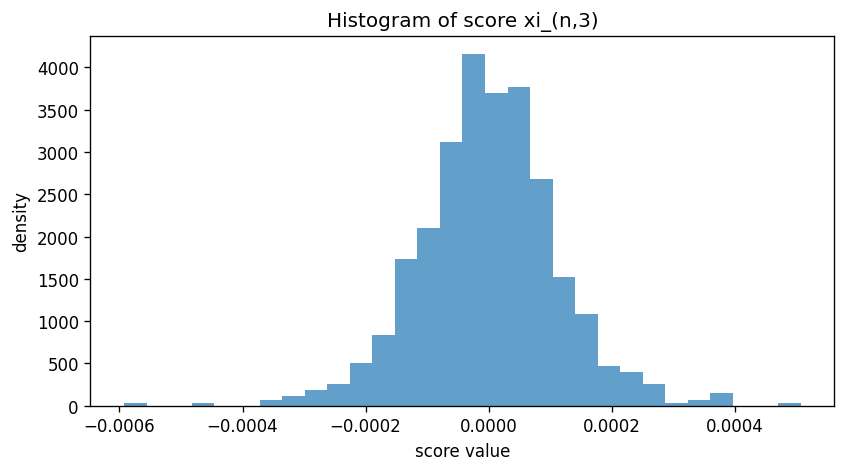

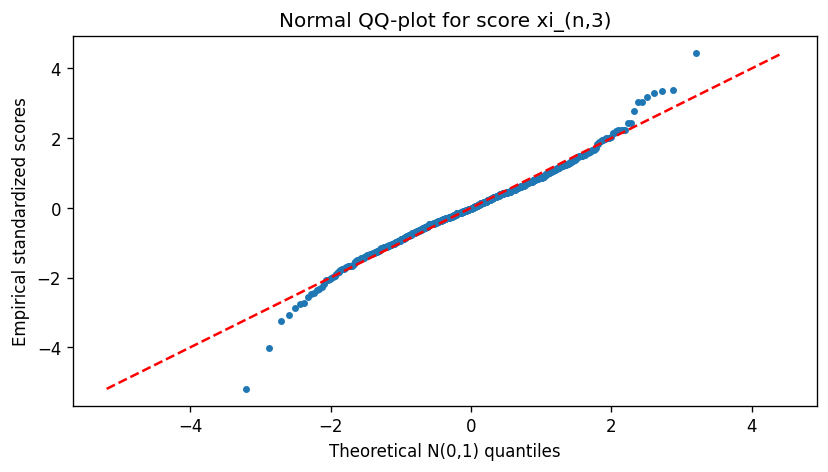


Score k = 4
  mean = -2.8759e-21
  var = 5.7710e-09
  skew = -3.4715e-02
  kurt = 3.7780e+00
  JB = 1.9168e+01
  JB_pvalue = 6.8836e-05


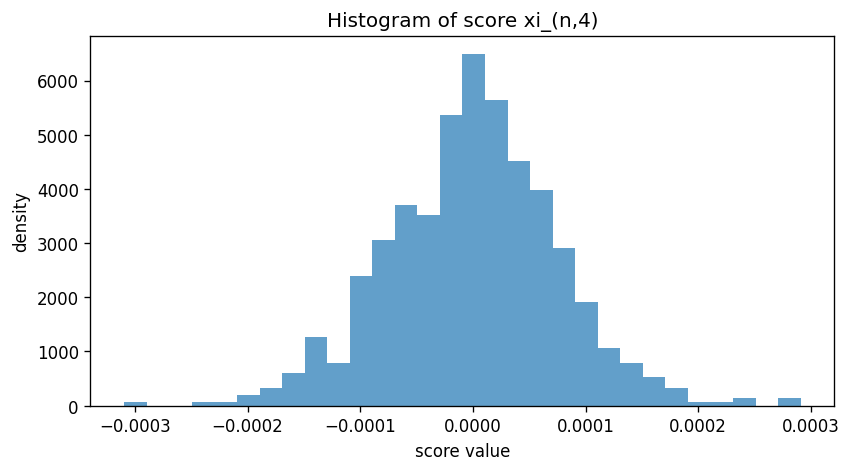

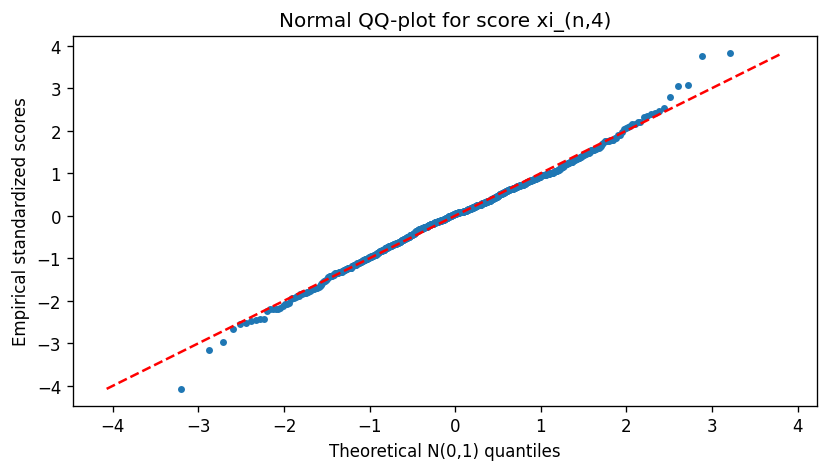


Score k = 5
  mean = 3.0197e-21
  var = 3.6815e-09
  skew = -3.3046e-02
  kurt = 3.5547e+00
  JB = 9.8047e+00
  JB_pvalue = 7.4289e-03


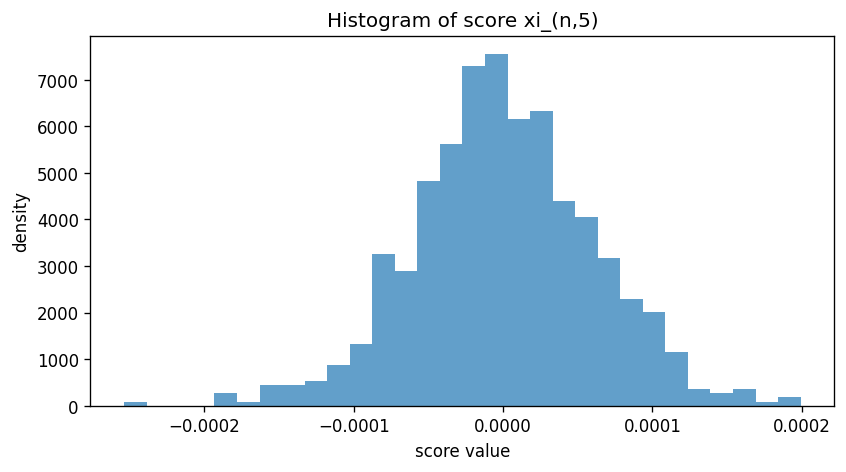

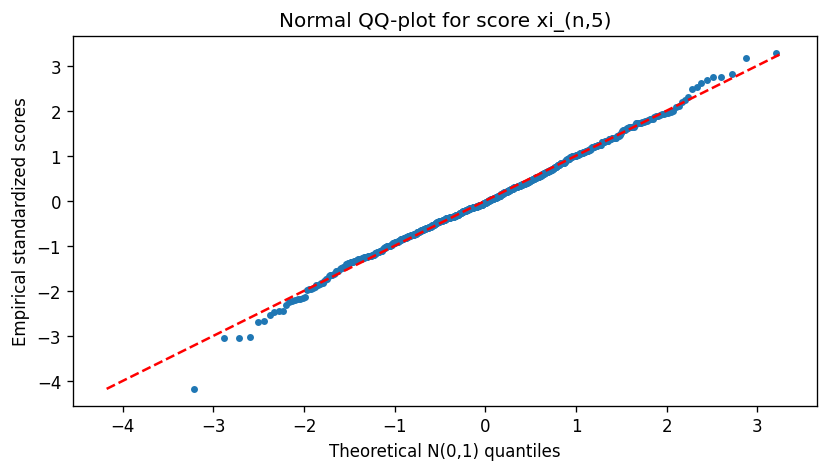


Score k = 6
  mean = 1.0785e-21
  var = 2.4379e-09
  skew = 5.0801e-02
  kurt = 3.9961e+00
  JB = 3.1495e+01
  JB_pvalue = 1.4489e-07


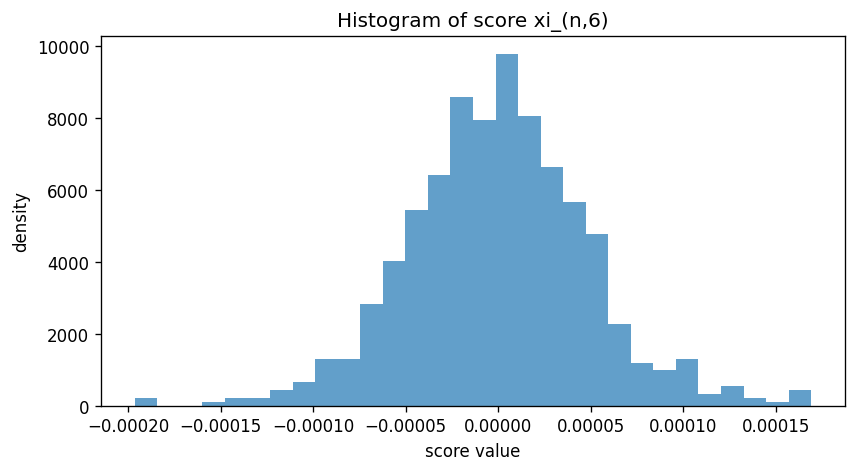

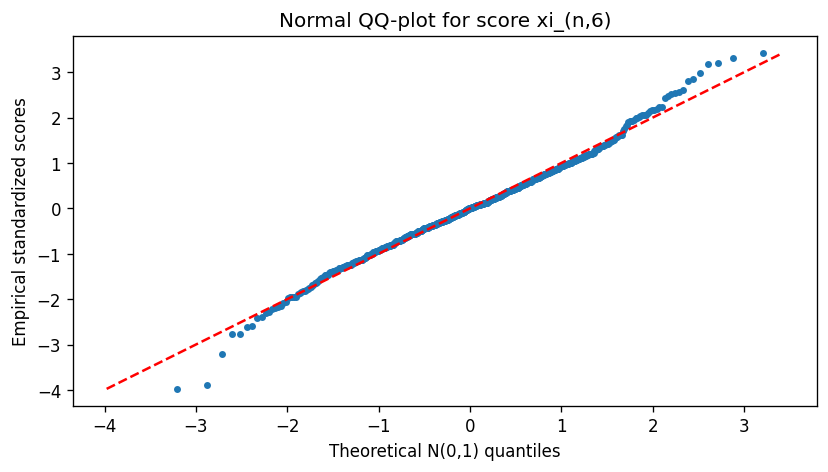


Score k = 7
  mean = 1.2941e-21
  var = 1.9534e-09
  skew = 2.7412e-01
  kurt = 4.5552e+00
  JB = 8.5425e+01
  JB_pvalue = 0.0000e+00


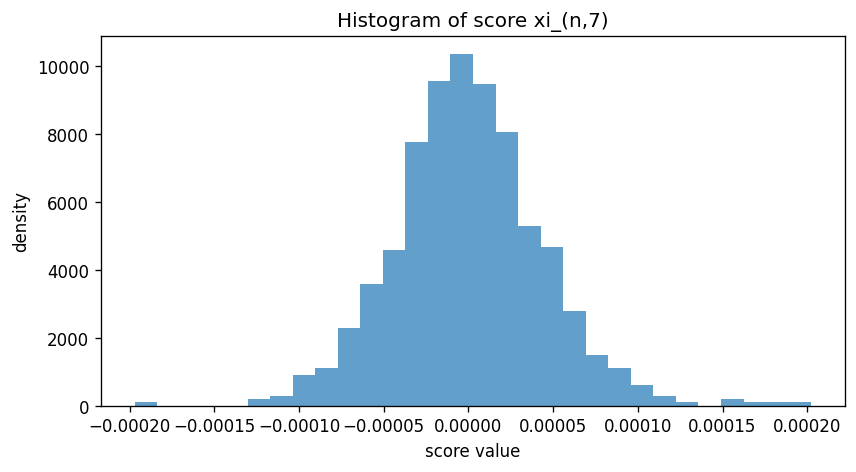

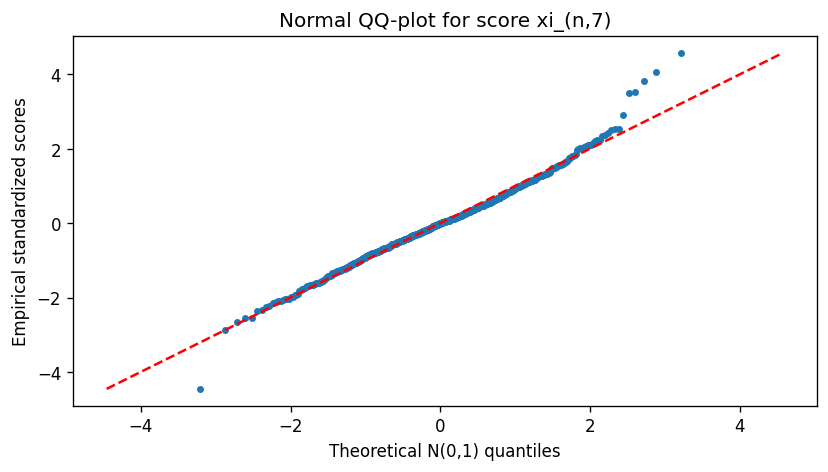


Score k = 8
  mean = -1.2941e-21
  var = 1.4576e-09
  skew = -3.1608e-01
  kurt = 4.5029e+00
  JB = 8.3516e+01
  JB_pvalue = 0.0000e+00


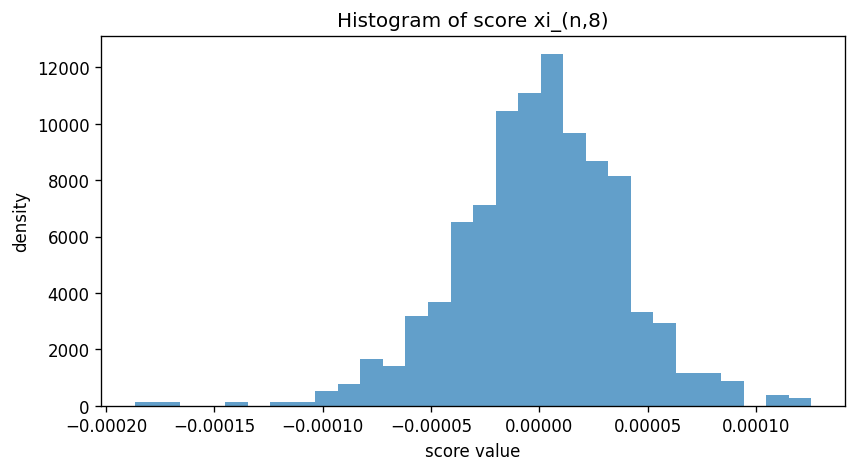

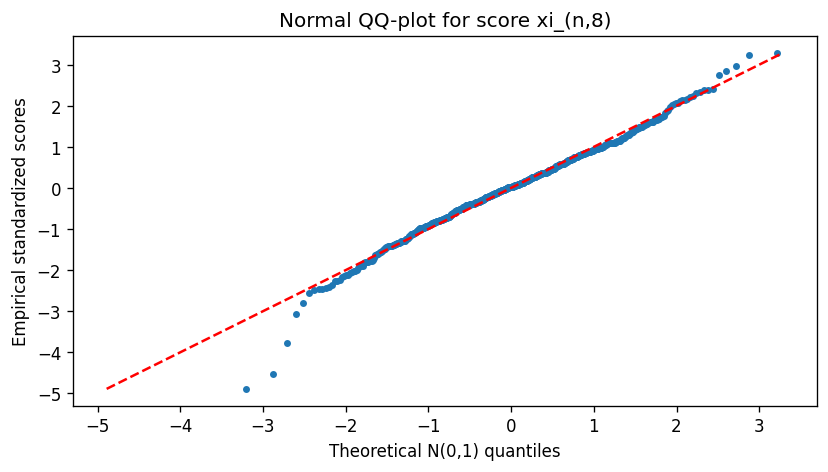


Score k = 9
  mean = 2.3007e-21
  var = 9.7106e-10
  skew = 3.4343e-03
  kurt = 3.7740e+00
  JB = 1.8823e+01
  JB_pvalue = 8.1765e-05


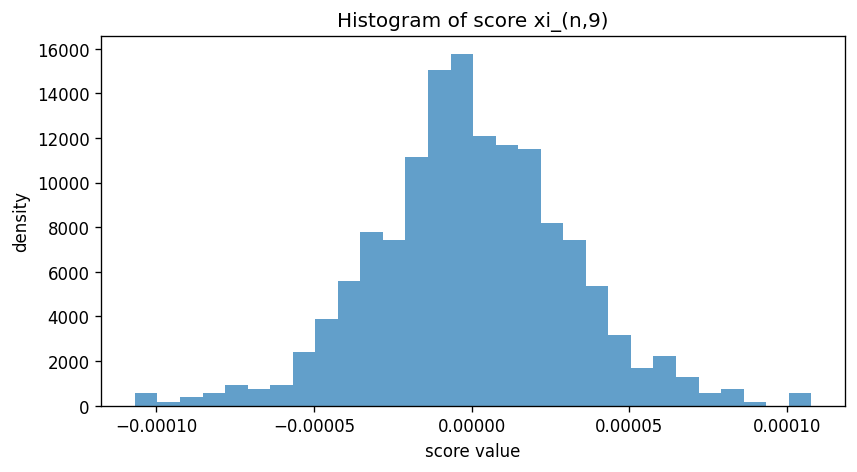

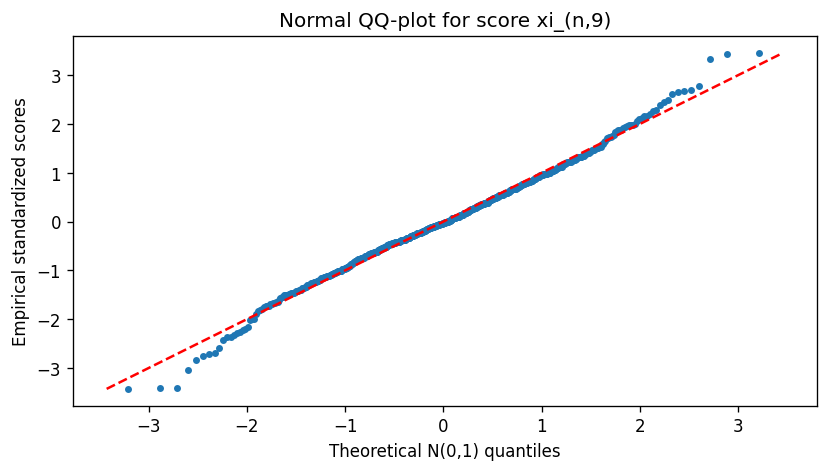


Score k = 10
  mean = -1.8693e-21
  var = 8.8097e-10
  skew = -1.9059e-01
  kurt = 3.2178e+00
  JB = 6.0549e+00
  JB_pvalue = 4.8440e-02


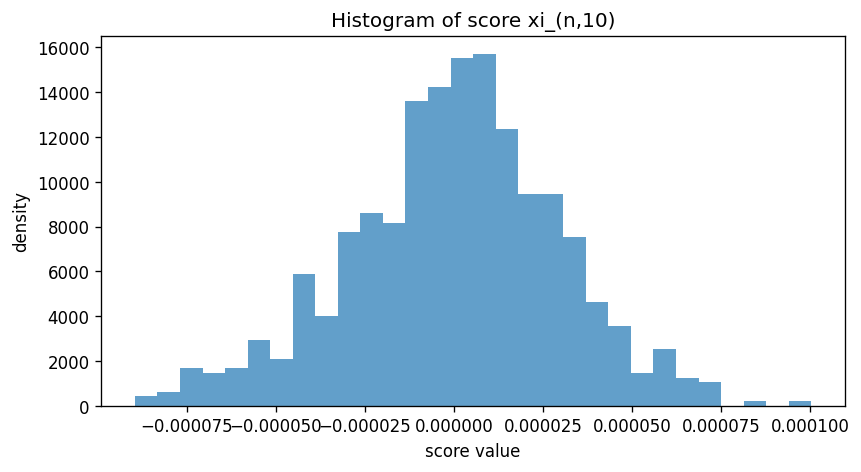

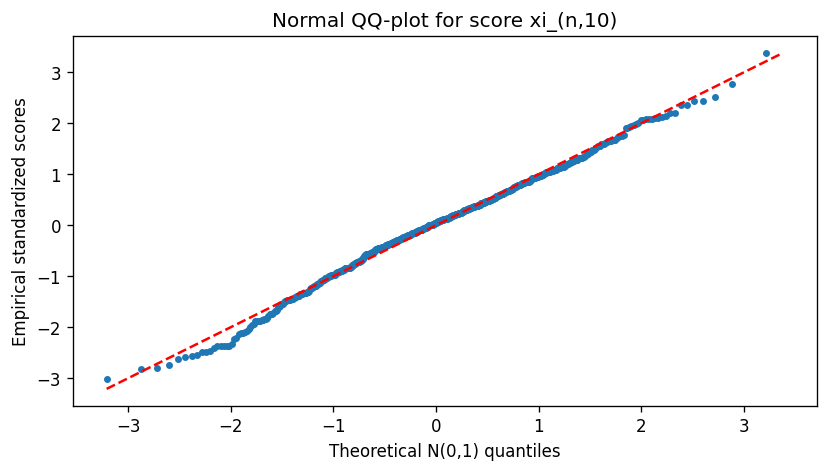

In [8]:
def empirical_moments(x: np.ndarray) -> dict:
    x = np.asarray(x)
    n = x.size
    mean = x.mean()
    var = ((x - mean) ** 2).sum() / (n - 1)
    sigma = np.sqrt(var)
    skew = ((x - mean) ** 3).sum() / (n * sigma ** 3)
    kurt = ((x - mean) ** 4).sum() / (n * sigma ** 4)
    JB = n * (skew**2 / 6.0 + (kurt - 3.0)**2 / 24.0)
    p_JB = 1 - chi2.cdf(JB, df=2)
    return {
        'mean': mean,
        'var': var,
        'skew': skew,
        'kurt': kurt,
        'JB': JB,
        'JB_pvalue': p_JB,
    }


for k in range(p_max):
    xk = Xi[:, k]
    stats = empirical_moments(xk)
    print('\nScore k =', k+1)
    for key, val in stats.items():
        print(f'  {key} = {val:.4e}')

    # Histogram
    plt.figure()
    plt.hist(xk, bins=30, density=True, alpha=0.7)
    plt.title(f'Histogram of score xi_(n,{k+1})')
    plt.xlabel('score value')
    plt.ylabel('density')
    plt.show()

    # Normal QQ-plot (standardised scores)
    z = (xk - stats['mean']) / np.sqrt(stats['var'])
    z_sorted = np.sort(z)
    n_ = len(z_sorted)
    probs = (np.arange(1, n_ + 1) - 0.5) / n_
    theo = norm.ppf(probs)

    plt.figure()
    plt.scatter(theo, z_sorted, s=10)
    minv = min(theo.min(), z_sorted.min())
    maxv = max(theo.max(), z_sorted.max())
    plt.plot([minv, maxv], [minv, maxv], 'r--')
    plt.xlabel('Theoretical N(0,1) quantiles')
    plt.ylabel('Empirical standardized scores')
    plt.title(f'Normal QQ-plot for score xi_(n,{k+1})')
    plt.show()

For each component $k$, the score series ${\xi_{nk}}_{n=1}^N$ is centered (the mean is numerically close to zero) and its variance decreases with $k$, as expected in FPCA. Skewness is modest, roughly between $-0.3$ and $0.3$, meaning the distributions are fairly symmetric. However, kurtosis is typically between 3.5 and 5, which is above the normal value of 3.

The Jarque–Bera test systematically rejects normality (very small p-values), but the histograms and QQ-plots give a more nuanced picture: the overall shape is close to Gaussian and the points follow the QQ-line quite well, with deviations mainly in the tails. In practice, we can say the scores are **approximately Gaussian in the center but with slightly heavier tails**, which is very common in financial data. For modeling, the assumption “approximately Gaussian with heavy tails” still looks reasonable.


## 5. ACF and Ljung–Box test on the scores

We test whether each score series $\left(\xi_{nk}\right)_{n=1}^{N}$ can be treated as white noise (i.e., no significant autocorrelation).



ACF + Ljung–Box pour score k=1
  Q1(K=10) = 9.3563, p-value = 0.4987


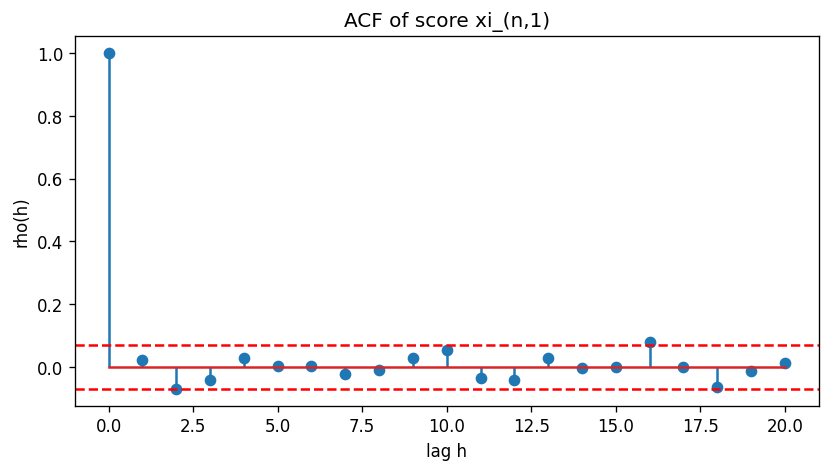


ACF + Ljung–Box pour score k=2
  Q1(K=10) = 7.1094, p-value = 0.7151


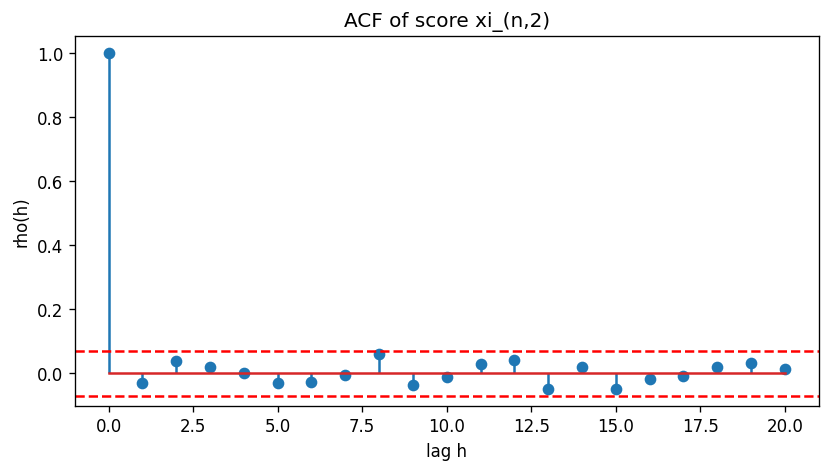


ACF + Ljung–Box pour score k=3
  Q1(K=10) = 13.0772, p-value = 0.2194


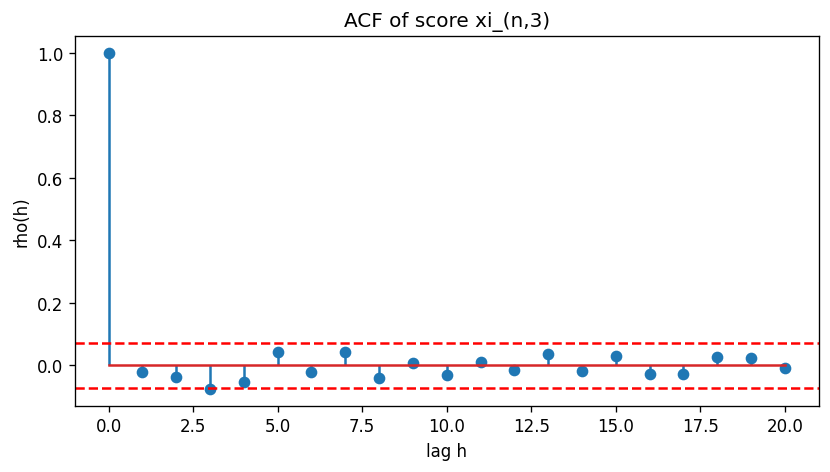


ACF + Ljung–Box pour score k=4
  Q1(K=10) = 3.9621, p-value = 0.9490


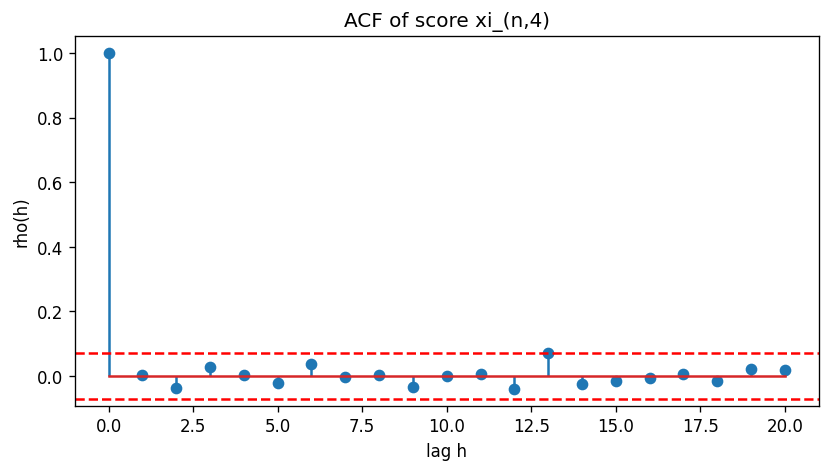


ACF + Ljung–Box pour score k=5
  Q1(K=10) = 15.6342, p-value = 0.1106


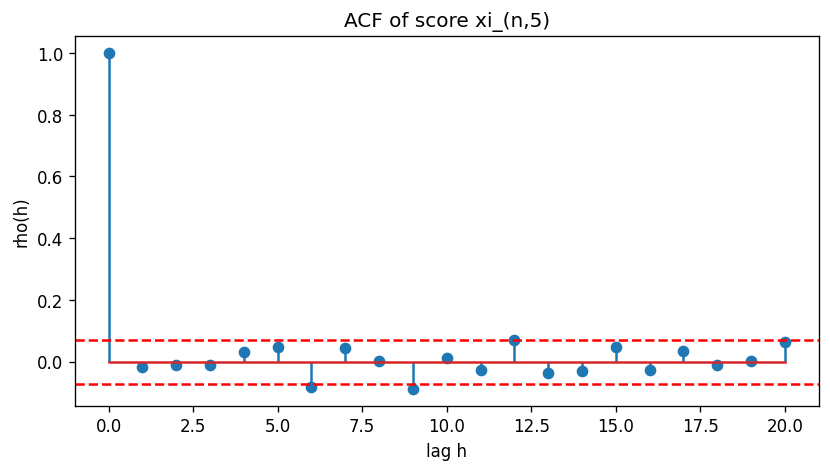


ACF + Ljung–Box pour score k=6
  Q1(K=10) = 8.3664, p-value = 0.5931


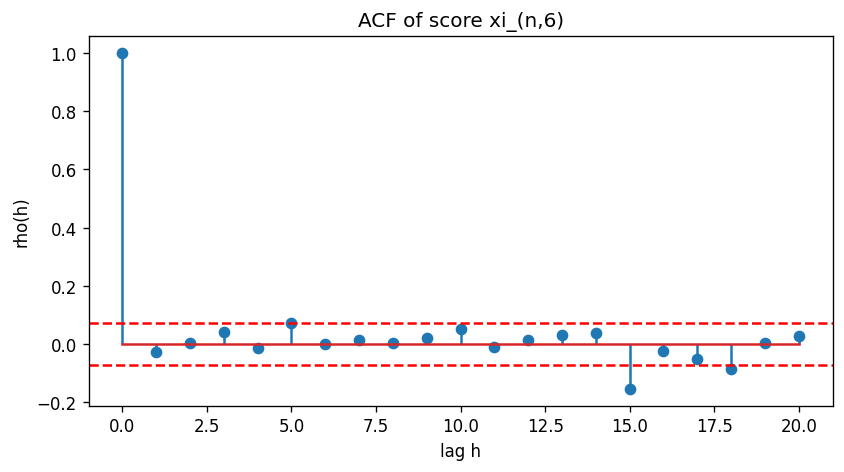


ACF + Ljung–Box pour score k=7
  Q1(K=10) = 7.4639, p-value = 0.6810


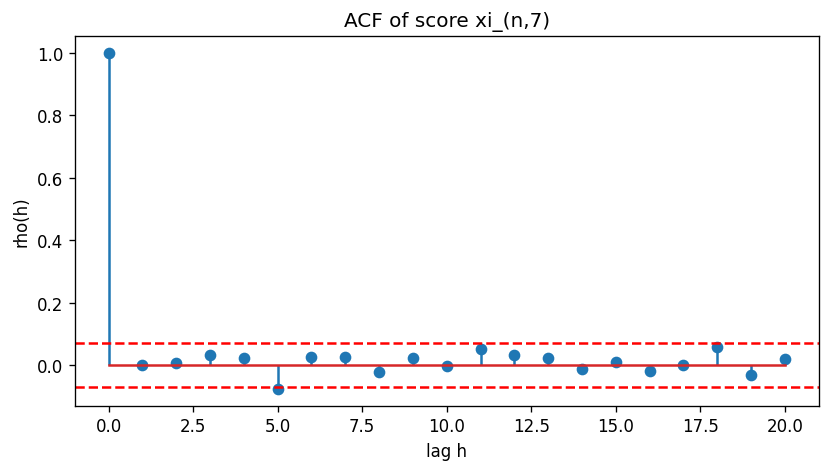


ACF + Ljung–Box pour score k=8
  Q1(K=10) = 11.9795, p-value = 0.2864


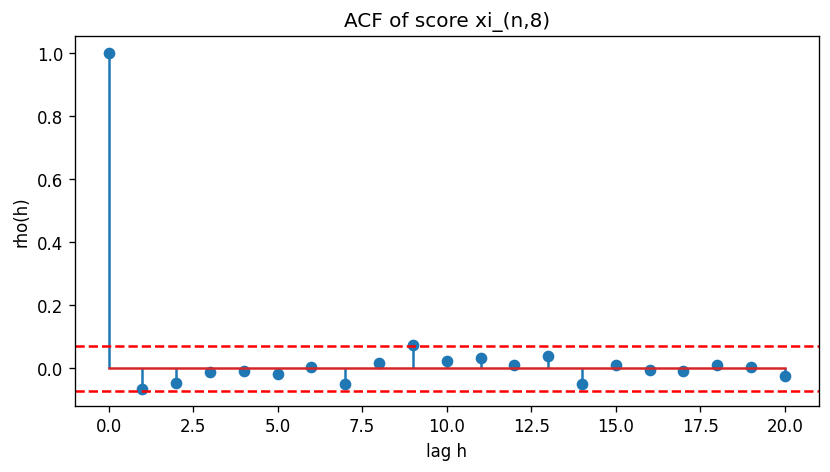


ACF + Ljung–Box pour score k=9
  Q1(K=10) = 9.1833, p-value = 0.5148


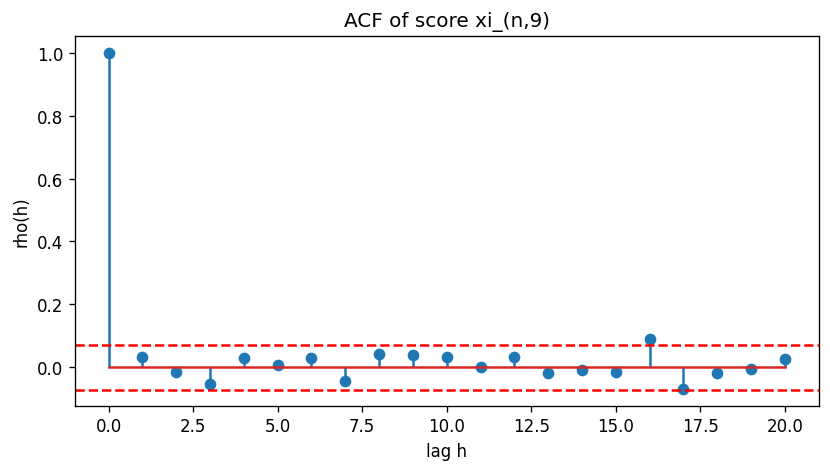


ACF + Ljung–Box pour score k=10
  Q1(K=10) = 7.3355, p-value = 0.6934


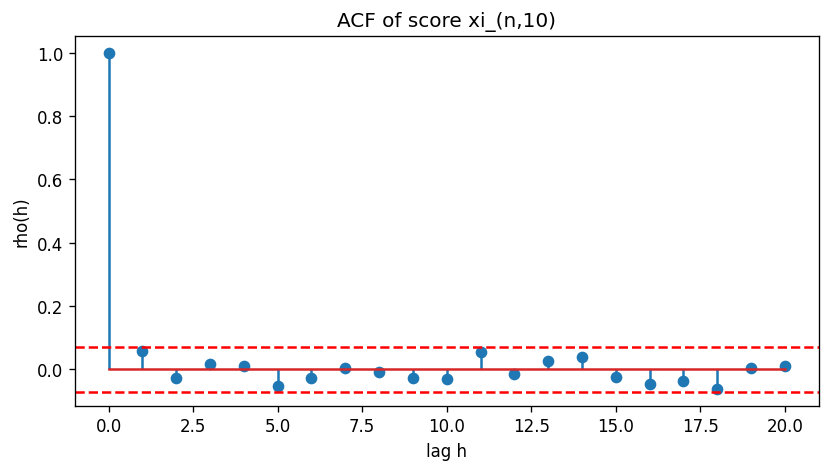

In [9]:
def acf(x: np.ndarray, max_lag: int) -> np.ndarray:
    x = np.asarray(x)
    n = x.size
    mean = x.mean()
    gamma0 = ((x - mean)**2).sum() / n
    acf_vals = np.empty(max_lag + 1)
    acf_vals[0] = 1.0
    for k in range(1, max_lag + 1):
        cov = ((x[k:] - mean) * (x[:-k] - mean)).sum() / n
        acf_vals[k] = cov / gamma0
    return acf_vals


def ljung_box(x: np.ndarray, K: int):
    x = np.asarray(x)
    n = x.size
    rho = acf(x, K)[1:]
    Q1 = n * (n + 2) * np.sum(rho**2 / (n - np.arange(1, K + 1)))
    pval = 1 - chi2.cdf(Q1, df=K)
    return Q1, pval


H = 20
K = 10

for k in range(p_max):
    xk = Xi[:, k]
    rho = acf(xk, H)
    Q1, pval = ljung_box(xk, K)

    print(f'\nACF + Ljung–Box pour score k={k+1}')
    print(f'  Q1(K={K}) = {Q1:.4f}, p-value = {pval:.4f}')

    n = len(xk)
    bound = 1.96 / sqrt(n)
    lags = np.arange(H + 1)

    plt.figure()
    plt.stem(lags, rho)
    plt.axhline(bound, color='red', linestyle='--')
    plt.axhline(-bound, color='red', linestyle='--')
    plt.title(f'ACF of score xi_(n,{k+1})')
    plt.xlabel('lag h')
    plt.ylabel('rho(h)')
    plt.show()

The ACF plots of the score series ${\xi_{nk}}_n$ show that, for every component $k$, the autocorrelations at lags 1 to 20 stay within the confidence bands $\pm 1.96/\sqrt{N}$. There is no clear significant spike and no slow decay that would suggest strong persistence. The Ljung–Box tests confirm this: for $K=10$, all p-values are well above the usual significance levels (5% or even 1%), so we do not reject the null hypothesis $\rho(1)=\dots=\rho(10)=0$.

Therefore, **for each component $k$**, the sequence $(\xi_{nk})_{n=1,\dots,N}$ is compatible with **white noise** (no detectable linear autocorrelation). In other words, even if the scores are not perfectly Gaussian, they do not display a strong simple time-dependence structure such as an AR(1).


## 6. Qualité du fit et estimation de \(\sigma^2\)

p=1, MSE_fpca(p) = 7.36687e-06
p=2, MSE_fpca(p) = 3.69662e-06
p=3, MSE_fpca(p) = 2.42413e-06
p=4, MSE_fpca(p) = 1.85922e-06
p=5, MSE_fpca(p) = 1.49885e-06
p=6, MSE_fpca(p) = 1.26020e-06
p=7, MSE_fpca(p) = 1.06899e-06
p=8, MSE_fpca(p) = 9.26310e-07
p=9, MSE_fpca(p) = 8.31254e-07
p=10, MSE_fpca(p) = 7.45018e-07


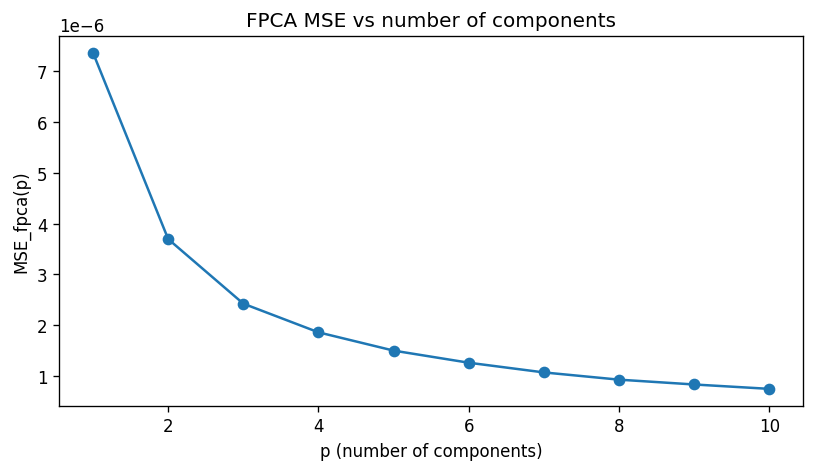


Estimation de la variance de bruit sigma^2 ≈ 7.450175467450971e-07


In [10]:
def mse_fpca(Y, mu_hat, Psi, Xi, p, dt):
    N, J = Y.shape
    Psi_p = Psi[:, :p]
    Xi_p = Xi[:, :p]
    X_hat = mu_hat + Xi_p @ Psi_p.T / dt
    residuals = Y - X_hat
    return np.mean(residuals**2)

p_list = list(range(1, p_max + 1))

MSE_fpca = []
for p in p_list:
    MSE_p = mse_fpca(Y, mu_hat, Psi, Xi, p, dt)
    MSE_fpca.append(MSE_p)
    print(f"p={p}, MSE_fpca(p) = {MSE_p:.5e}")

plt.figure()
plt.plot(p_list, MSE_fpca, marker='o')
plt.xlabel('p (number of components)')
plt.ylabel('MSE_fpca(p)')
plt.title('FPCA MSE vs number of components')
plt.show()

sigma2_hat = MSE_fpca[-1]
print('\nEstimation de la variance de bruit sigma^2 ≈', sigma2_hat)


The reconstruction MSE $\text{MSE}_{\text{fpca}}(p)$ decreases quickly when moving from 1 to 3–4 components: for example, it goes from $7.4\times 10^{-6}$ with $p=1$ to about $1.9\times 10^{-6}$ with $p=4$. After that, the improvement becomes much more gradual and the curve tends to flatten out, reaching a plateau around $7.5\times 10^{-7}$ for $p=10$.

This “elbow” shape is typical: the first components capture the main structure of the functional trajectories, while higher-order components mainly correct small local fluctuations. The MSE plateau can be interpreted as an estimate of the **noise variance $\sigma^2$** in the model $Y_n = X_n + \varepsilon_n$. Here we get $\hat\sigma^2 \approx 7.5\times 10^{-7}$, which is relatively small compared to the variance explained by the first components. Overall, this suggests that **a few components (around 2 to 4) are enough for a good fit**, and beyond that the gain is limited relative to the noise level.


## 7. AR(1) model on the scores and functional forecasting


In [11]:
# Choice of p_model: first p such that the cumulative PVE is at least 0.90
p_model = int(np.argmax(pve >= 0.9) + 1)
p_model = min(p_model, p_max)

print('Nombre de composantes retenu pour le modèle : p_model =', p_model)

Psi_p = Psi[:, :p_model]
Xi_p = Xi[:, :p_model]

# Train / test split
train_frac = 0.8
N_train = int(train_frac * N)
N_test = N - N_train
print('N_train =', N_train, ', N_test =', N_test)

Xi_train = Xi_p[:N_train, :]
Xi_test = Xi_p[N_train:, :]


# Estimate AR(1) coefficient alpha_k = rho_k(1) on the training sample
alpha_hat = np.zeros(p_model)
for k in range(p_model):
    rho_train = acf(Xi_train[:, k], max_lag=1)
    alpha_hat[k] = rho_train[1]
    print(f'alpha_hat[{k+1}] = {alpha_hat[k]:.4f}')


def one_step_forecast_scores_AR1(Xi_all, alpha_hat, N_train):
    N_all, p = Xi_all.shape
    Xi_tilde = np.zeros((N_all, p))
    for n in range(N_train, N_all):
        Xi_tilde[n, :] = alpha_hat * Xi_all[n-1, :]
    return Xi_tilde


Xi_tilde = one_step_forecast_scores_AR1(Xi_p, alpha_hat, N_train)

# Reconstruct the predicted curves from the predicted scores
X_tilde = np.zeros_like(Y)
X_tilde[:] = mu_hat
X_tilde += Xi_tilde @ Psi_p.T / dt

Nombre de composantes retenu pour le modèle : p_model = 2
N_train = 603 , N_test = 151
alpha_hat[1] = -0.0123
alpha_hat[2] = -0.0408


For the time-series model on the scores, we keep $p_{\text{model}} = 2$ components, which already explains more than 93% of the total variance. The estimated AR(1) parameters are $\hat\alpha_1 \approx -0.012$ and $\hat\alpha_2 \approx -0.041$, i.e., very close to zero.

These values are consistent with the ACF and Ljung–Box diagnostics: **the scores behave almost like white noise**, with no significant autocorrelation. As a result, an AR(1) model brings only a very small improvement compared with a “white-noise” baseline where the best one-step-ahead forecast is simply zero. In other words, the day-to-day dynamics of the FPCA scores looks hardly predictable with a simple linear model.


## 8. Forecast error on the test period


Average forecast MSE (test) = 5.390255736177183e-05


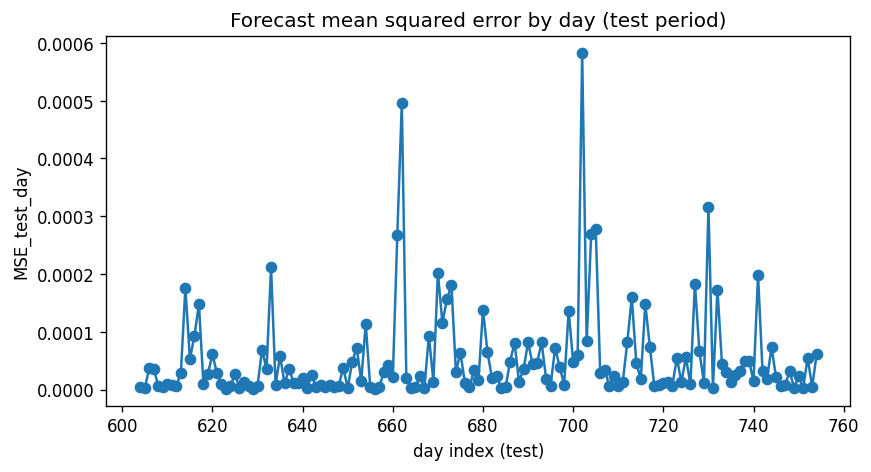

In [12]:
# Test-day MSE (average over intraday grid points)
MSE_test_day = np.mean((Y[N_train:, :] - X_tilde[N_train:, :])**2, axis=1)

# Average forecast MSE over all test days
MSE_test_mean = np.mean(MSE_test_day)

print("Average forecast MSE (test) =", MSE_test_mean)

# Plot the day-by-day forecast error over the test period
plt.figure()
plt.plot(range(N_train + 1, N + 1), MSE_test_day, marker="o")
plt.xlabel("day index (test)")
plt.ylabel("MSE_test_day")
plt.title("Forecast mean squared error by day (test period)")
plt.show()


Over the test period (the last 151 days), the average forecast MSE is about $5.4\times 10^{-5}$. This corresponds to an RMSE of roughly $\sqrt{5.4\times 10^{-5}} \approx 7\times 10^{-3}$, i.e. around 0.7% in terms of cumulative log-return. This error is still moderate compared to the typical amplitude of the curves $Y_n(t)$ (often between $-2%$ and $+2%$), but it shows that forecasting an entire future intraday trajectory is difficult.

This fits the general idea: even though FPCA reconstructs the **average shape** of intraday profiles very well (low in-sample reconstruction MSE), the **day-to-day fluctuations of the scores** are almost unpredictable. As a result, the forecast MSE is much larger than the reconstruction MSE, which is normal: we move from “explaining an observed curve” to “guessing tomorrow’s curve from yesterday’s.” For this asset and horizon, the AR(1) model on the scores gives reasonable forecasts but does not significantly reduce uncertainty, which is typical for financial time series.
